In [2]:
import stereo as st
import warnings
warnings.filterwarnings('ignore')

In [3]:
import scanpy as sc

In [4]:
adata=st.io.read_ann_h5ad('./data/st-merge.h5ad')

In [5]:
adata

StereoExpData object with n_cells X n_genes = 2782519 X 10676
bin_type: None
offset_x = None
offset_y = None
cells: ['cell_name', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts']
genes: ['gene_name']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []

In [6]:
adata.cells

,total_counts,pct_counts_mt,n_genes_by_counts
M-3W-MG_15302968476141,None,None,None
M-3W-MG_15255723835843,None,None,None
M-3W-MG_15174119457263,None,None,None
M-3W-MG_15075335209422,None,None,None
M-3W-MG_15066745274848,None,None,None
...,...,...,...
S-LA-MG_30739080947720,None,None,None
S-LA-MG_30734785980446,None,None,None
S-LA-MG_30872224933899,None,None,None
S-LA-MG_30816390359062,None,None,None


In [7]:
adata.tl.cal_qc()

[2025-12-02 16:51:45][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run cal_qc...
[2025-12-02 16:51:52][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: cal_qc end, consume time 7.1012s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

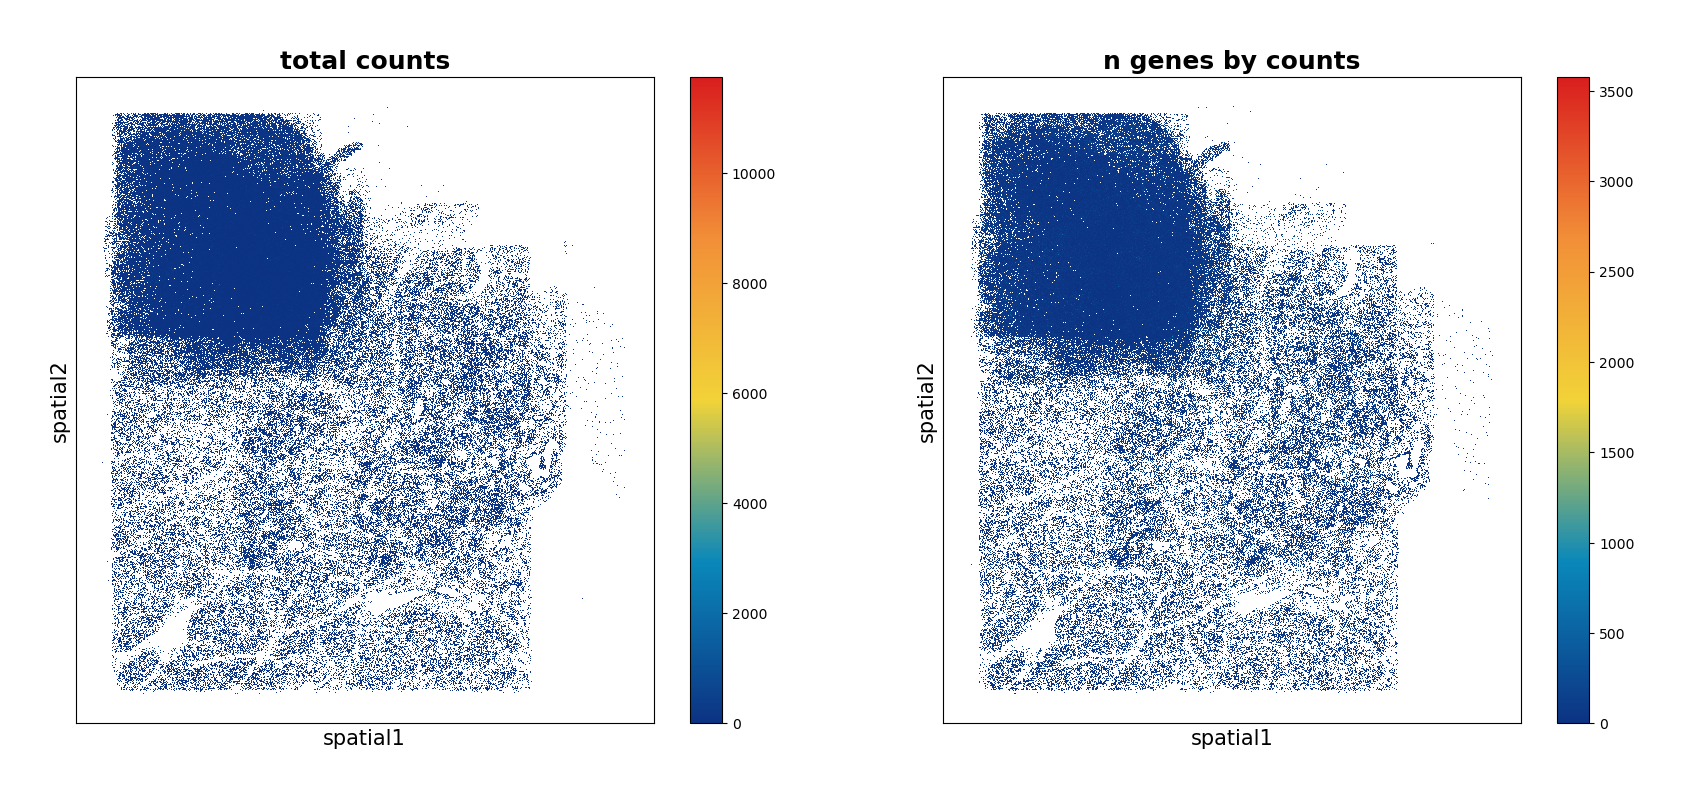

In [8]:
adata.plt.spatial_scatter()

In [9]:
import numpy as np

# 1. 获取所有细胞名称
cell_names = adata.cells.cell_name

# 2. 提取样本名 (以最后一个下划线为界拆分)
# 逻辑：取 'Sample_Name_CellID' 中最后一个 '_' 左边的所有内容
batch_list = [name.rsplit('_', 1)[0] for name in cell_names]

# 3. 将提取出的样本列表赋值给 adata.cells.batch
# 这一步就完成了类似 "adata.obs['sample'] = ..." 的操作
adata.cells.batch = np.array(batch_list)

# 4. 打印看一下有哪些样本，以及每个样本有多少细胞
unique_batches, counts = np.unique(adata.cells.batch, return_counts=True)
print(f"共检测到 {len(unique_batches)} 个样本。")
print("-" * 30)
for sample, count in zip(unique_batches, counts):
    print(f"样本: {sample:<30} | 细胞数: {count}")

共检测到 21 个样本。
------------------------------
样本: M-3W-MG                        | 细胞数: 32474
样本: M-5W-MG                        | 细胞数: 45024
样本: M-8W-MG                        | 细胞数: 49626
样本: M-GES135-MG                    | 细胞数: 45081
样本: M-LA-MG                        | 细胞数: 102325
样本: R-10W-AG                       | 细胞数: 99627
样本: R-10W-MG                       | 细胞数: 242689
样本: R-14W-MG                       | 细胞数: 239567
样本: R-23W-AG                       | 细胞数: 150621
样本: R-23WK-MG                      | 细胞数: 72191
样本: R-GES17-MG                     | 细胞数: 142220
样本: R-LA-AG                        | 细胞数: 133010
样本: R-LA-MG                        | 细胞数: 650803
样本: S-3M-AG                        | 细胞数: 84484
样本: S-3M-MG                        | 细胞数: 21089
样本: S-5-8M-AG                      | 细胞数: 87152
样本: S-5M-MG                        | 细胞数: 103724
样本: S-8M-MG                        | 细胞数: 53352
样本: S-GES14-MG                     | 细胞数: 184597
样本: S-LA-AG                        

正在提取并绘制样本: S-LA-AG ...


[2025-12-02 16:54:03][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run cal_qc...
[2025-12-02 16:54:03][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: cal_qc end, consume time 0.1052s.


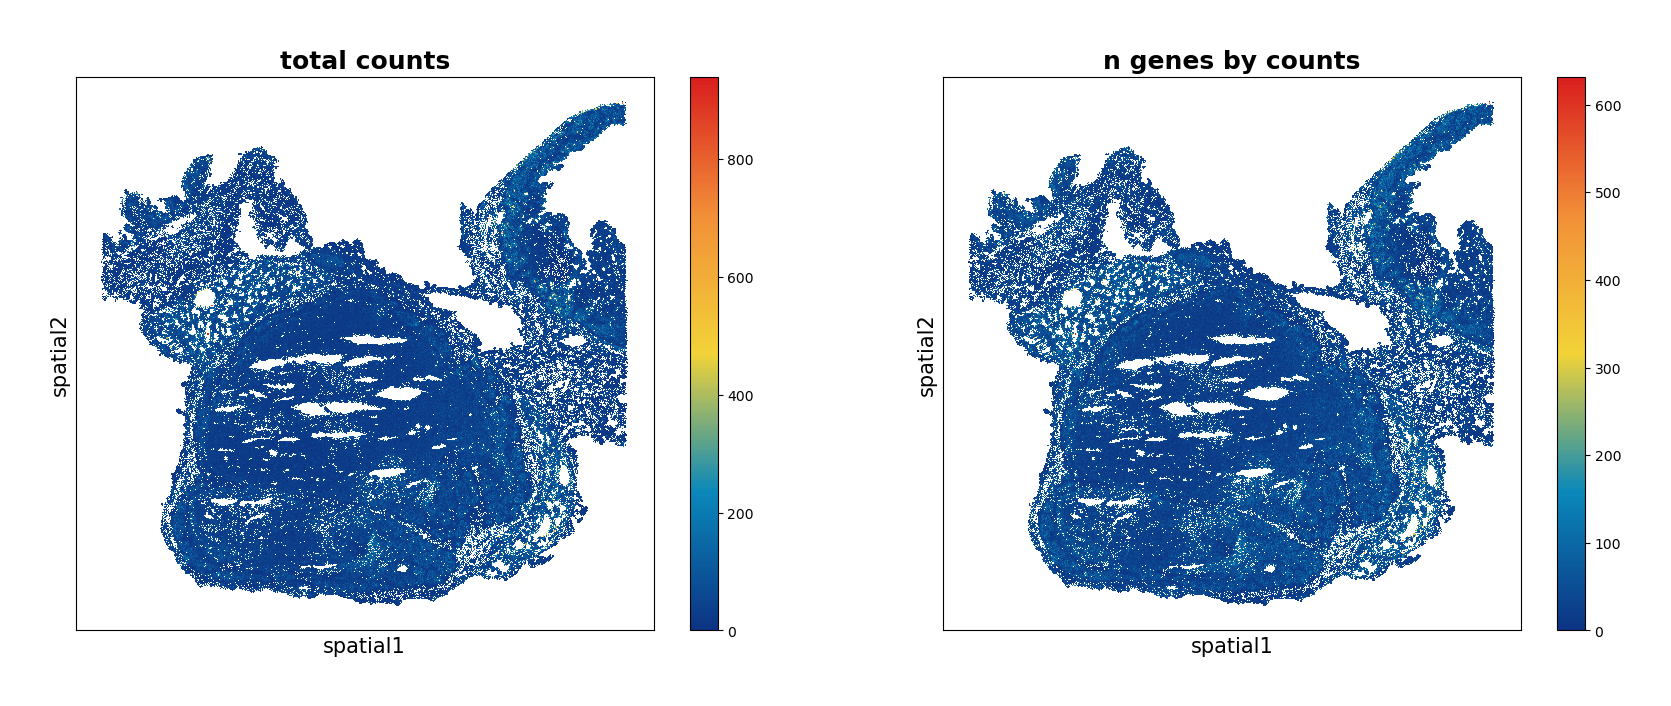

In [10]:
# --- 在这里修改你想看的样本名称 ---
target_sample = 'S-LA-AG'  # <--- 将这里替换为你上面打印出来的某个具体样本名
# -------------------------------

print(f"正在提取并绘制样本: {target_sample} ...")

# 1. 利用刚刚赋值的 batch 属性找到对应的索引
# np.where 返回的是满足条件的索引位置
target_indices = np.where(adata.cells.batch == target_sample)[0]

if len(target_indices) == 0:
    print("错误：未找到该样本，请检查名称拼写！")
else:
    # 2. 基于索引提取子集 (Subsetting)
    # 这会生成一个新的 adata 对象，只包含该样本的数据
    sub_adata = adata.sub_by_index(target_indices)
    
    # 3. 重新计算 QC (为了画图颜色更准确，防止还是 None)
    sub_adata.tl.cal_qc()
    
    # 4. 画图
    # 此时画出来的应该就是一个干净、独立的组织切片了
    sub_adata.plt.spatial_scatter(
    )

In [11]:
sub_adata

StereoExpData object with n_cells X n_genes = 141492 X 10676
bin_type: None
offset_x = None
offset_y = None
cells: ['cell_name', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'batch']
genes: ['gene_name', 'n_cells', 'n_counts', 'mean_umi']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

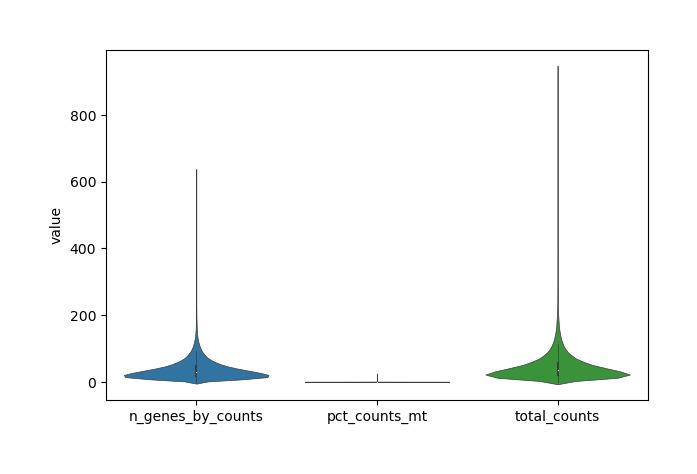

In [12]:
sub_adata.plt.violin()

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

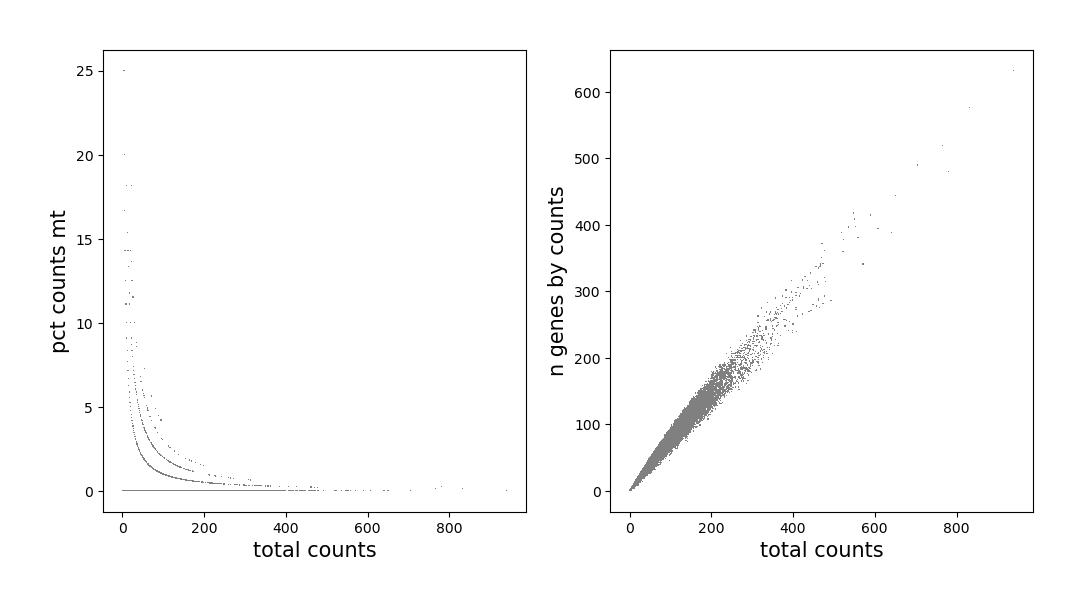

In [13]:
sub_adata.plt.genes_count()

In [14]:
sub_adata.tl.filter_cells(
        min_counts=200,
        min_genes=3,
        max_genes=2500,
        pct_counts_mt=5,
        inplace=True
        )
data=sub_adata

[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run filter_cells...
[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: filter_cells end, consume time 0.0744s.


In [15]:
data.tl.raw_checkpoint()

In [16]:
data.tl.raw

StereoExpData object with n_cells X n_genes = 1271 X 10676
bin_type: None
offset_x = None
offset_y = None
cells: ['cell_name', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'batch']
genes: ['gene_name', 'n_cells', 'n_counts', 'mean_umi']
cells_matrix = ['spatial']
Layers with keys: 
tl.result: []

In [17]:
data.tl.normalize_total()
data.tl.log1p()

[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run normalize_total...
[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: normalize_total end, consume time 0.0156s.
[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run log1p...
[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: log1p end, consume time 0.0062s.


In [18]:
data.tl.highly_variable_genes(
            min_mean=0.0125,
            max_mean=3,
            min_disp=0.5,
            n_top_genes=3000,
            res_key='highly_variable_genes'
            )

[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run highly_variable_genes...
[2025-12-02 16:54:15][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: highly_variable_genes end, consume time 0.2019s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

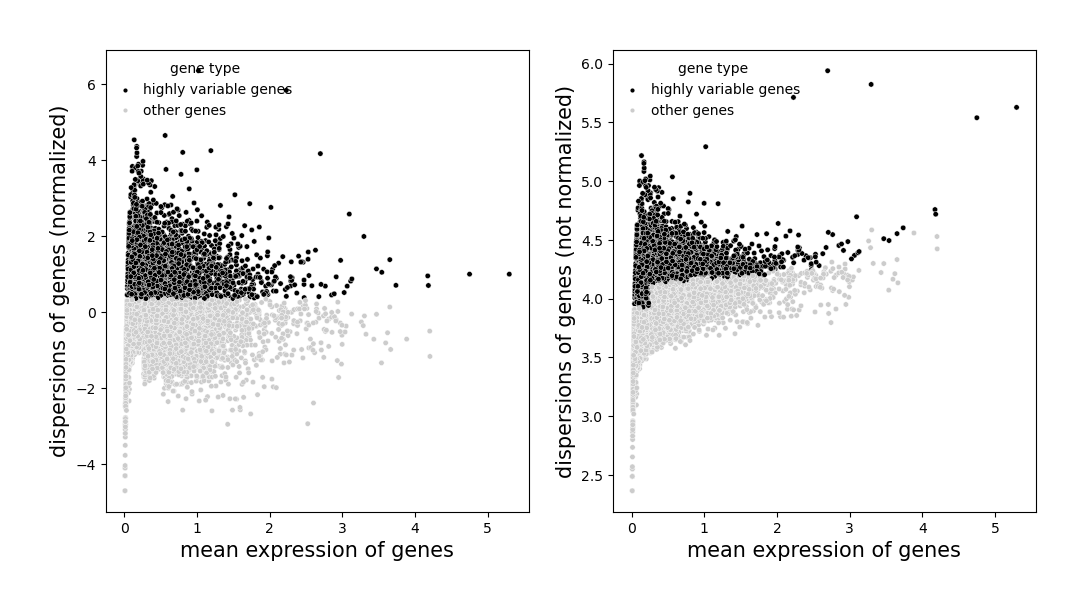

In [19]:
data.plt.highly_variable_genes(res_key='highly_variable_genes')

In [20]:
data.tl.scale()

[2025-12-02 16:54:16][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run scale...
[2025-12-02 16:54:17][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: scale end, consume time 0.1377s.


In [21]:
data.tl.pca(
        use_highly_genes=True,
        n_pcs=10,
        res_key='pca'
        )

[2025-12-02 16:54:17][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run pca...
[2025-12-02 16:54:17][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: pca end, consume time 0.5365s.


[2025-12-02 16:54:17][Stereo][234385][MainThread][47552828976512][plot_collection][84][INFO]: register plot_func elbow to <stereo.plots.plot_collection.PlotCollection object at 0x2b44bd123790>


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

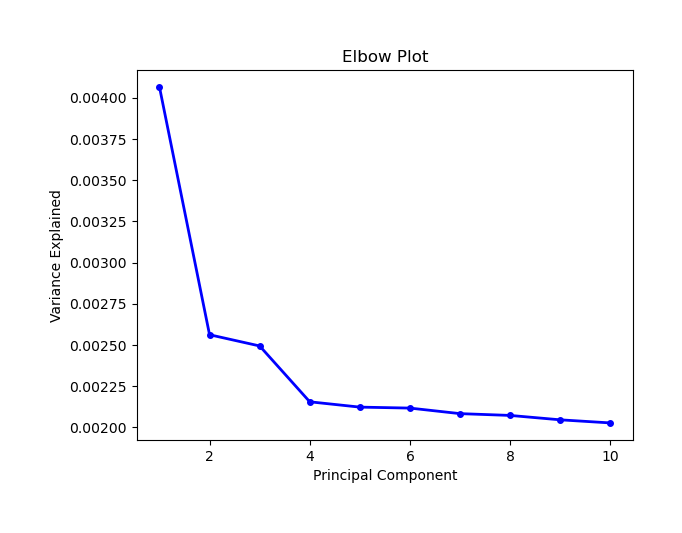

In [22]:
data.plt.elbow(pca_res_key='pca')

In [23]:
data.tl.neighbors(pca_res_key='pca', res_key='neighbors')

[2025-12-02 16:54:17][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run neighbors...
[2025-12-02 16:54:25][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: neighbors end, consume time 7.1687s.


In [24]:
data.tl.umap(
        pca_res_key='pca',
        neighbors_res_key='neighbors',
        res_key='umap'
        )

[2025-12-02 16:54:25][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run umap...


	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs


[2025-12-02 16:54:27][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: umap end, consume time 2.8494s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

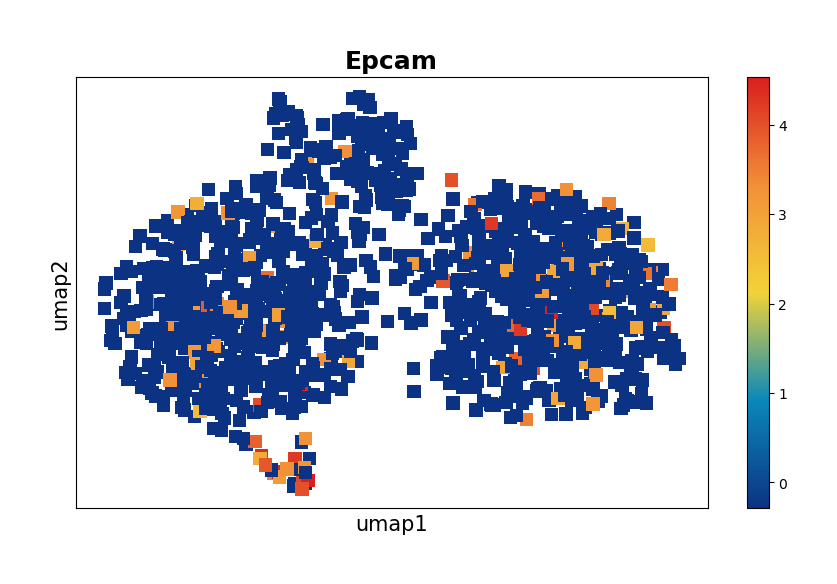

In [25]:
data.plt.umap(gene_names=['Epcam', 'Lalba'], res_key='umap')

In [26]:
data.tl.leiden(neighbors_res_key='neighbors',res_key='leiden')

[2025-12-02 16:54:28][Stereo][234385][MainThread][47552828976512][st_pipeline][41][INFO]: start to run leiden...
[2025-12-02 16:54:28][Stereo][234385][MainThread][47552828976512][st_pipeline][44][INFO]: leiden end, consume time 0.1045s.


Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

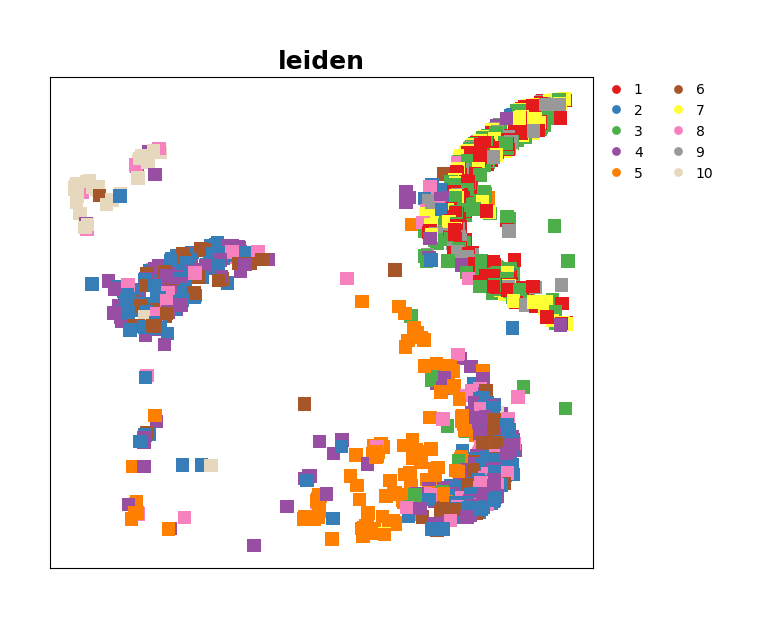

In [32]:
data.plt.cluster_scatter(res_key='leiden',)

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

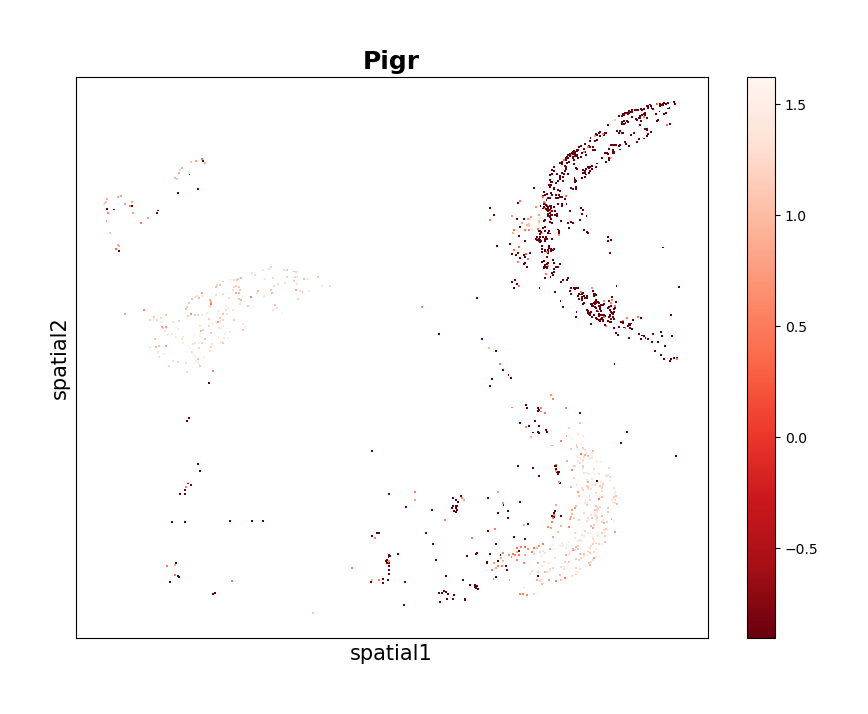

In [38]:
sub_adata.plt.spatial_scatter_by_gene(
    gene_name=['Pigr'],   # 参数名是 gene_name，支持列表
    dot_size=2,           # 点大小
    palette='Reds'        # 颜色板
)

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

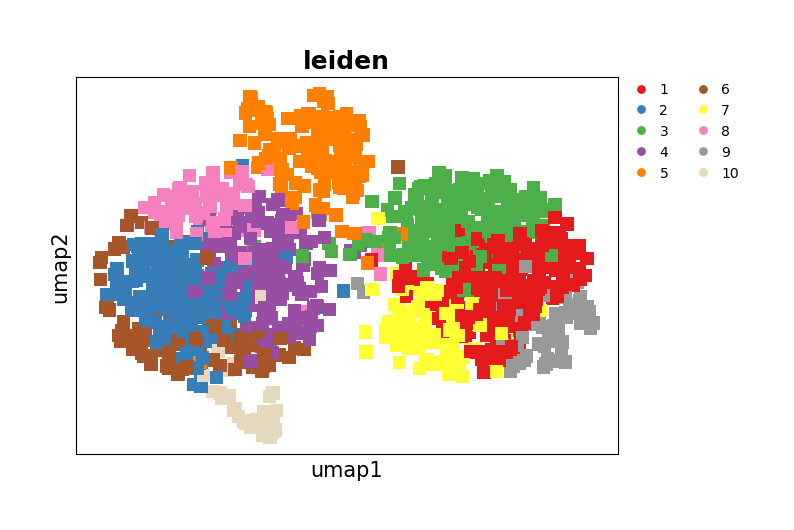

In [28]:
data.plt.umap(res_key='umap', cluster_key='leiden')

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

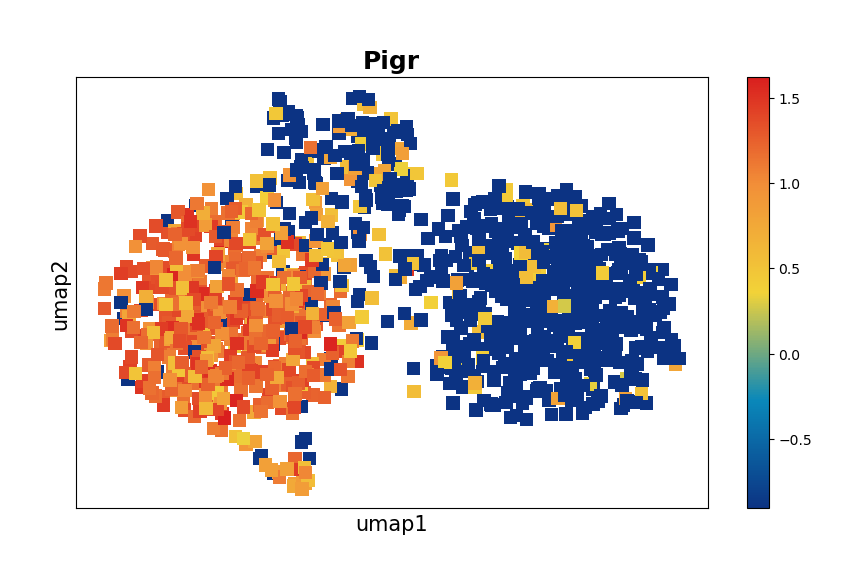

In [30]:
data.plt.umap(gene_names=['Pigr'], res_key='umap')

Column
    [0] Markdown(str)
    [1] Row
        [0] TextInput(name='file name', placeholder='Enter a file name...', width=200)
        [1] Select(name='file format', options=['png', 'pdf'], value='png', width=60)
        [2] IntInput(name='dpi', placeholder='Enter the dip...', start=0, value=100, width=200)
    [2] Row
        [0] Button(button_type='primary', name='export', width=100)
        [1] StaticText(width=800)

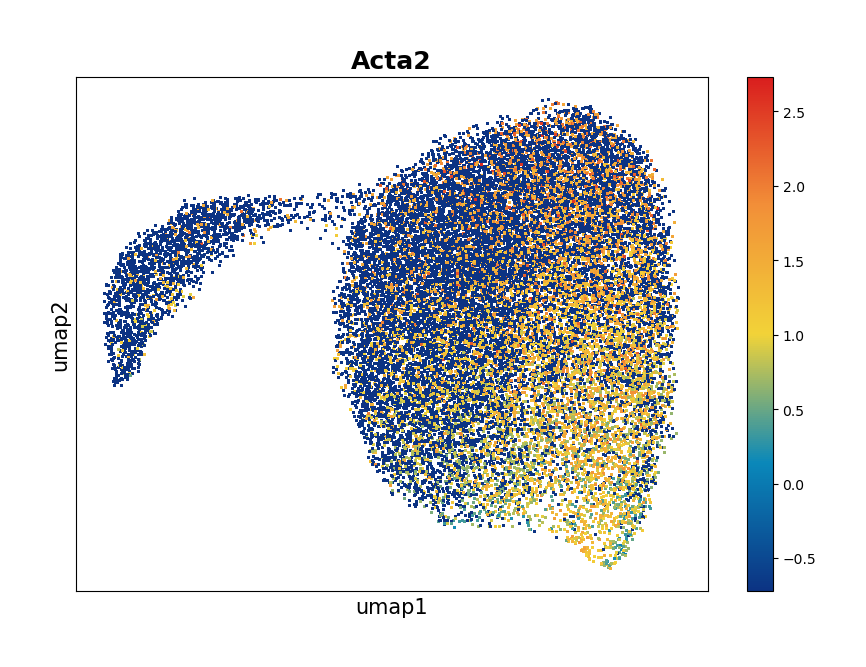

In [61]:
data.plt.umap(gene_names=['Acta2'], res_key='umap')

In [1]:
import cell2location

ModuleNotFoundError: No module named 'cell2location'